<a href="https://colab.research.google.com/github/PhysikDidaktikUniAugsburg/Federn-Topologie-Quanten/blob/main/Von_echten_Federn_zur_Topologie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Von echten Federn zur Topologie in der Quantenphysik

## Einleitung
Ziel dieses Workshops ist es, das Verhalten von Massen, die unterschiedlich miteinander verbunden sind, zu beschreiben. Betrachte beispielsweise die folgende Abbildung:

<div>
<img src="https://github.com/PhysikDidaktikUniAugsburg/Federn-Topologie-Quanten/blob/main/pictures/5%20Messen%20%C3%BCber%20Federn%20gekoppelt%20-%20Latex.png?raw=true" width="750"/>
</div>

Was passiert, wenn man beispielsweise die Masse ganz links auslenkt und dann loslässt?

## Python
Um dieses und ähnliche Probleme zu lösen, verwenden wir Computersimulationen, welche mit Python geschrieben wurden. Python ist eine Standard-Programmiersprache in verschiedenen Wissenschaften, weil sie einerseits leicht zu verwenden ist und andererseits für verschiedenste Zwecke eingesetzt werden kann. Innerhalb von diesem Notebook gibt es Text-Zellen wie diese und Python-Code-Bausteine wie die Zelle unten. In den Code-Zellen kannst du Python direkt ausführen, indem du dauf das ▶️ Symbol oben klickst.

<div style="padding: 15px; border-left: 6px solid #2196F3; background-color: #E3F2FD; color: #0D47A1; border-radius: 4px;">
    <strong>Aufgabe:</strong><br>
    Erkunde den Code unten, indem du ihn mit ▶️ ausführst. Korrigiere den Fehler im Code und gib der Tür die gleiche Farbe, die das Dach hat.
</div>


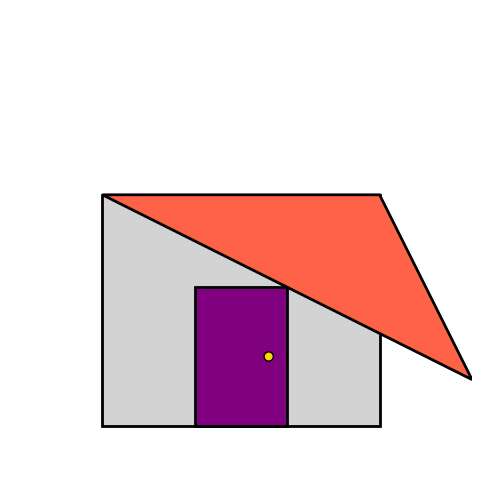

In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Grafik und Achsen erstellen
fig, ax = plt.subplots(figsize=(6, 6))

# --- HINTERGRUND (Himmel) ---
ax.set_facecolor('blue')

# --- HAUSWAND ---
# Ein Rechteck: (X, Y von links unten), Breite, Höhe, Farbe
wand = patches.Rectangle((2, 1), 6, 5, facecolor='lightgray', edgecolor='black', linewidth=2)
ax.add_patch(wand)

# --- DACH ---
# Ein Dreieck aus drei Koordinaten-Punkten: Links(2,6) -> Spitze(10,2) -> Rechts(8,6)
dach_punkte = [[2, 6], [10, 2], [8, 6]]
dach = patches.Polygon(dach_punkte, facecolor='tomato', edgecolor='black', linewidth=2)
ax.add_patch(dach)

# --- TÜR ---
tuer = patches.Rectangle((4, 1), 2, 3, facecolor='purple', edgecolor='black', linewidth=2)
ax.add_patch(tuer)

# --- TÜR KNAUF ---
knauf = patches.Circle((5.6, 2.5), 0.1, facecolor='gold', edgecolor='black')
ax.add_patch(knauf)

# 2. Achseneinstellungen (Damit alles gut sichtbar und nicht verzerrt ist)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal') # Verhindert, dass das Haus verzerrt wird

# Achsen-Beschriftungen ausblenden, damit es wie ein echtes Bild aussieht
plt.axis('off')

# Grafik anzeigen
plt.show()

## Teil 1: Echte Massen, die mit Federn gekoppelt sind

(Foto von 5 über Federn gekoppelten Massen einfügen)

... dieser Aufbau gegeben, erst mal in echt testen, dann simulieren

In [ ]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display

# 1. Regler für die Anzahl der Pendel N
N_widget = widgets.IntSlider(value=3, min=2, max=8, description='Anzahl N:')

# Container für unsere dynamischen Zeilen
matrix_ui_container = widgets.VBox()

# Hier speichern wir die Referenzen auf die Eingabefelder ab
input_fields = {}

def update_equation_ui(change):
    # Lese den aktuellen Wert von N aus
    N = change['new'] if isinstance(change, dict) else change
    rows = []
    input_fields.clear()

    for i in range(1, N + 1):
        row_items = []
        # Linke Seite der Gleichung: \ddot{x}_i =
        row_items.append(widgets.HTMLMath(value=rf"$\ddot{{x}}_{i} =$"))

        for j in range(1, N + 1):
            # Vorbelegung der Werte (Sinnvolle Standardwerte für eine lineare Kette)
            standard_val = -2.0 if i == j else (1.0 if abs(i-j) == 1 else 0.0)

            # Das Eingabefeld (die "___" vor dem x)
            w = widgets.FloatText(value=standard_val, step=0.1, layout=widgets.Layout(width='60px'))
            input_fields[(i, j)] = w
            row_items.append(w)

            # Rechte Seite: x_j (und ein Plus, wenn es nicht das letzte Element ist)
            plus = " $+$ " if j < N else ""
            row_items.append(widgets.HTMLMath(value=rf"$x_{j}${plus}"))

        # Füge alle Elemente einer Gleichung horizontal zusammen
        rows.append(widgets.HBox(row_items, layout=widgets.Layout(align_items='center')))

    # Aktualisiere die Anzeige
    matrix_ui_container.children = rows

# Verknüpfe den Slider mit der Update-Funktion
N_widget.observe(update_equation_ui, names='value')

# Baue die UI für den Startwert einmalig auf
update_equation_ui(N_widget.value)

# Zeige die Elemente im Notebook an
display(N_widget)
display(matrix_ui_container)

In [ ]:
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp
from IPython.display import display, Markdown

# 1. Matrix A aus der grafischen Oberfläche (Block 1) auslesen
N = N_widget.value
A = np.zeros((N, N))

for i in range(1, N + 1):
    for j in range(1, N + 1):
        # Wir schreiben die Werte aus den Feldern in das Numpy-Array
        A[i-1, j-1] = input_fields[(i, j)].value

# 1. Überschrift schön formatiert ausgeben
display(Markdown("**Die aktuell eingestellte Matrix $A$ lautet:**"))

# 2. Die Numpy-Matrix in eine SymPy-Matrix umwandeln und rendern
display(sp.Matrix(A))

# 2. Die Simulation (wie im vorherigen Schritt)
def derivative(t, y):
    x = y[0:N]
    v = y[N:2*N]

    dxdt = v
    dvdt = A @ x

    return np.concatenate((dxdt, dvdt))

# Wir lenken das erste Pendel aus
y0 = np.zeros(2 * N)
y0[0] = 1.0

t_span = (0, 30)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

sol = solve_ivp(derivative, t_span, y0, t_eval=t_eval)

# 3. Plotting
plt.figure(figsize=(12, 6))
for i in range(N):
    plt.plot(sol.t, sol.y[i], label=f'Pendel {i+1} ($x_{i+1}$)')

plt.title(f'Schwingung von {N} Pendeln')
plt.xlabel('Zeit t')
plt.ylabel('Auslenkung $\\vec{x}$')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Die Zeichenfläche (fig) und die zwei Bereiche erstellen ---
fig, (ax_anim, ax_graph) = plt.subplots(2, 1, figsize=(10, 10))

# --- 2. Setup für die Pendel-Animation (Oben) ---
pendulum_spacing = 2.0
x_centers = np.arange(N) * pendulum_spacing

ax_anim.set_xlim(-1.5, (N-1) * pendulum_spacing + 1.5)
ax_anim.set_ylim(-1.5, 0.5)
ax_anim.set_aspect('equal')
ax_anim.grid(True, linestyle='--', alpha=0.5)
ax_anim.set_title(f"Physische Bewegung von {N} gekoppelten Pendeln")

lines_anim = [ax_anim.plot([], [], '-', lw=2, color=f'C{i}')[0] for i in range(N)]
particles_anim = [ax_anim.plot([], [], 'o', ms=10, color=f'C{i}')[0] for i in range(N)]
L = 1.0

# --- 3. Setup für den Graphen (Unten) ---
ax_graph.set_xlim(sol.t[0], sol.t[-1])
y_max = np.max(np.abs(sol.y)) * 1.2
ax_graph.set_ylim(-y_max, y_max)
ax_graph.set_title("Auslenkung über die Zeit")
ax_graph.set_xlabel('Zeit t')
ax_graph.set_ylabel('Auslenkung $\\vec{x}$')
ax_graph.grid(True)

for i in range(N):
    ax_graph.plot(sol.t, sol.y[i], color=f'C{i}', alpha=0.3, label=f'Pendel {i+1}')
ax_graph.legend(loc='upper right')

points_graph = [ax_graph.plot([], [], 'o', ms=8, color=f'C{i}')[0] for i in range(N)]
time_line = ax_graph.axvline(x=0, color='gray', linestyle='--', alpha=0.8)

# --- 4. Vorbereitung der Animations-Schleife ---
fps = 30
total_frames = len(sol.t)
step = 3
frames_to_render = range(0, total_frames, step)

bild_zaehler = 0
anzahl_bilder = len(frames_to_render)

def init():
    for line, particle in zip(lines_anim, particles_anim):
        line.set_data([], [])
        particle.set_data([], [])
    for point in points_graph:
        point.set_data([], [])
    time_line.set_xdata([0])
    return lines_anim + particles_anim + points_graph + [time_line]

def animate(frame):
    global bild_zaehler
    bild_zaehler += 1
    # Fortschritt in der gleichen Zeile überschreiben
    print(f"\rBild {bild_zaehler} von {anzahl_bilder} fertig", end="", flush=True)

    current_t = sol.t[frame]

    for i in range(N):
        theta = sol.y[i][frame]

        # Oben: Pendel bewegen
        x_pos = x_centers[i] + L * np.sin(theta)
        y_pos = -L * np.cos(theta)
        lines_anim[i].set_data([x_centers[i], x_pos], [0, y_pos])
        particles_anim[i].set_data([x_pos], [y_pos])

        # Unten: Punkte auf dem Graphen bewegen
        points_graph[i].set_data([current_t], [theta])

    time_line.set_xdata([current_t])
    return lines_anim + particles_anim + points_graph + [time_line]

# --- 5. Animation erstellen und anzeigen ---
ani = FuncAnimation(fig, animate, init_func=init, frames=frames_to_render,
                    interval=(1000/fps) * step, blit=True)

# Verhindert, dass eine statische Grafik zusätzlich zum Video ausgegeben wird
plt.close(fig)

# Zeilenumbruch, damit das fertige Video den Lade-Text nicht verschluckt
print("\nVideo wird in das Notebook geladen...")
display(HTML(ani.to_jshtml()))